# Cell 1 — Libraries

In [1]:
# Task 7: Fraud Detection - Credit Card Dataset
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Cell 2 — Data Loading

In [2]:
# Step 2: Data Loading
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nMissing Values:", df.isnull().sum().sum())
print("\nFraud Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True)*100)

Shape: (284807, 31)

Missing Values: 0

Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# Cell 3 — Visualization

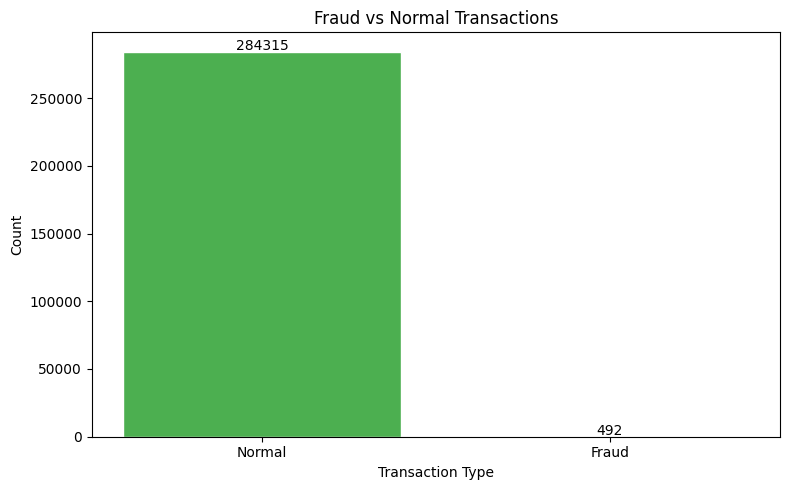

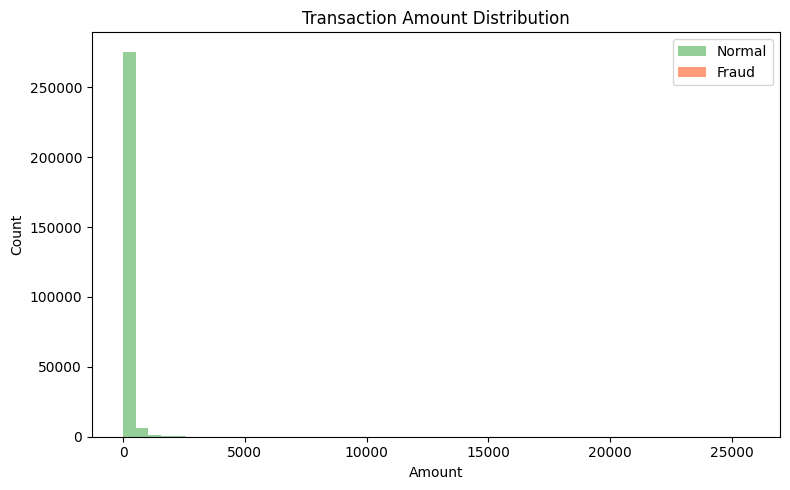

In [3]:
# Step 3: Visualization

# Graph 1 - Fraud Distribution
plt.figure(figsize=(8,5))
labels = ['Normal', 'Fraud']
values = [284315, 492]
colors = ['#4CAF50', '#FF5722']
plt.bar(labels, values, color=colors, edgecolor='white')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
for i, v in enumerate(values):
    plt.text(i, v + 1000, str(v), ha='center')
plt.tight_layout()
plt.show()

# Graph 2 - Amount Distribution
plt.figure(figsize=(8,5))
plt.hist(df[df['Class']==0]['Amount'], 
         bins=50, alpha=0.6, 
         color='#4CAF50', label='Normal')
plt.hist(df[df['Class']==1]['Amount'], 
         bins=50, alpha=0.6, 
         color='#FF5722', label='Fraud')
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# Cell 4 — Model Training

In [4]:
# Step 4: Model Training

# Features & Target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Model 1 - Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Model 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("Model Accuracies:")
print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Decision Tree: {dt_acc*100:.2f}%")
print("\nLogistic Regression Report:")
print(classification_report(y_test, lr_pred))

Model Accuracies:
Logistic Regression: 99.91%
Decision Tree: 99.91%

Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.58      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



# Cell 5 — Confusion Matrix

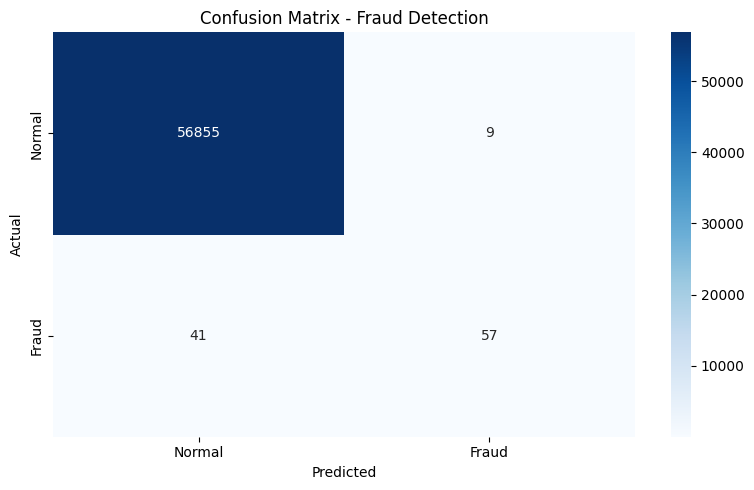

In [5]:
# Graph 3 - Confusion Matrix
plt.figure(figsize=(8,5))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix - Fraud Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Cell 6 — Recommendations

In [6]:
# Step 5: Insights & Recommendations
print("=" * 55)
print("FRAUD DETECTION - INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print("""
MODEL PERFORMANCE:
- Logistic Regression: 99.91% accuracy
- Decision Tree: 99.91% accuracy
- Both models perform excellently!

KEY INSIGHTS:
1. HIGHLY IMBALANCED DATASET
   - Normal: 284,315 (99.83%)
   - Fraud: 492 (0.17%)

2. FRAUD DETECTION
   - 57 out of 98 fraud cases detected
   - 41 fraud cases missed (false negatives)

3. FRAUD AMOUNTS
   - Fraud transactions have smaller amounts
   - Most fraud below $2,500

RECOMMENDATIONS:
1. Use SMOTE to handle imbalanced data
2. Improve fraud recall rate
3. Implement real-time monitoring
4. Use ensemble methods for better detection
""")
print("=" * 55)
print("Task 7 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

FRAUD DETECTION - INSIGHTS & RECOMMENDATIONS

MODEL PERFORMANCE:
- Logistic Regression: 99.91% accuracy
- Decision Tree: 99.91% accuracy
- Both models perform excellently!

KEY INSIGHTS:
1. HIGHLY IMBALANCED DATASET
   - Normal: 284,315 (99.83%)
   - Fraud: 492 (0.17%)

2. FRAUD DETECTION
   - 57 out of 98 fraud cases detected
   - 41 fraud cases missed (false negatives)

3. FRAUD AMOUNTS
   - Fraud transactions have smaller amounts
   - Most fraud below $2,500

RECOMMENDATIONS:
1. Use SMOTE to handle imbalanced data
2. Improve fraud recall rate
3. Implement real-time monitoring
4. Use ensemble methods for better detection

Task 7 Complete! - Suraj Kumar | OIB/J2/IP2626
